# 01 · Exploratory data analysis

**Question.** What does the data look like, and what does that imply for the analysis that follows: how complete is it, how are returns distributed, is volatility predictable, and how do the stocks move together?

Everything is read from PostgreSQL (never the live API) and computed with functions from `src/`. Run `python scripts/update_data.py --skip-fetch` first.

*FinSight is an analytics tool, not investment advice.*

## 1. Data

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import text

from src.database import queries
from src.database.connection import get_engine

pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 9})
ACCENT, GREY = "#1f4e79", "#8c8c8c"

with get_engine().connect() as conn:
    companies = queries.load_companies(conn)
    prices = queries.load_prices_ohlc(conn)
    statements = queries.load_statements(conn)
    metrics = queries.load_metrics(conn)
    quality = pd.read_sql(text("""SELECT * FROM core.data_quality_summary
                                  ORDER BY run_id DESC LIMIT 1"""), conn).iloc[0]
print(f"{len(companies) - 1} companies + benchmark | {len(prices):,} price rows | "
      f"{len(statements):,} statement rows | {len(metrics):,} metric rows")

25 companies + benchmark | 32,243 price rows | 7,347 statement rows | 6,146 metric rows


In [2]:
traded = prices[~prices["is_stale_quote"]]
coverage = traded.groupby("ticker").agg(first=("date", "min"), last=("date", "max"),
                                        days=("date", "size"))
coverage["placeholder_rows"] = prices[prices["is_stale_quote"]].groupby("ticker").size()
coverage = coverage.fillna(0).astype({"placeholder_rows": int})
print(f"Price history: {coverage['first'].min()} to {coverage['last'].max()}; "
      f"{coverage['days'].min()} to {coverage['days'].max()} trading days per ticker; "
      f"{int(coverage['placeholder_rows'].sum())} placeholder rows flagged and excluded.")
print(f"Latest validation run: {int(quality['total_records']):,} records, "
      f"{int(quality['invalid_records'])} invalid, pass rate {quality['pass_rate_pct']:.2f}%, "
      f"{quality['missing_pct']:.1f}% of applicable statement fields missing.")
coverage.head(8)

Price history: 2021-10-06 to 2026-10-06; 1230 to 1235 trading days per ticker; 170 placeholder rows flagged and excluded.
Latest validation run: 42,224 records, 8 invalid, pass rate 99.98%, 23.2% of applicable statement fields missing.


,first,last,days,placeholder_rows
ticker,,,,
ASIANPAINT.NS,2021-10-06,2026-10-06,1234,7
AXISBANK.NS,2021-10-06,2026-10-06,1234,7
BAJAJ-AUTO.NS,2021-10-06,2026-10-06,1233,7
BRITANNIA.NS,2021-10-06,2026-10-05,1230,10
CIPLA.NS,2021-10-06,2026-10-06,1234,7
DIVISLAB.NS,2021-10-06,2026-10-05,1233,6
DRREDDY.NS,2021-10-06,2026-10-06,1234,6
EICHERMOT.NS,2021-10-06,2026-10-05,1233,6


### Statement completeness

Share of *applicable* fields that have a value. Fields that do not apply to a sector type (gross profit for a bank) are outside the denominator.

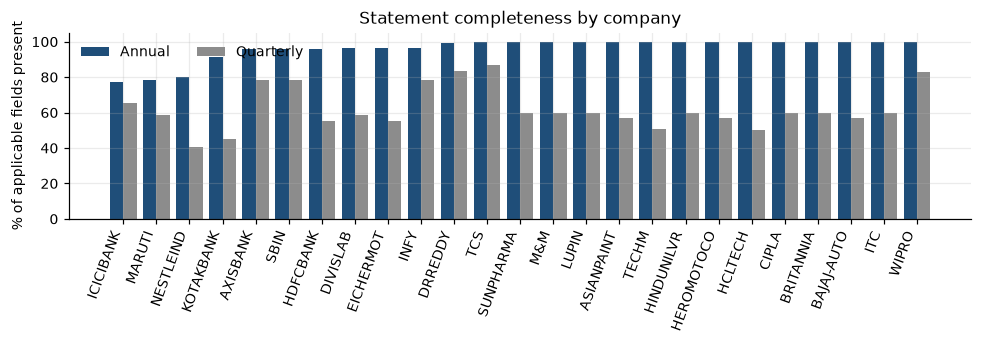

Annual completeness: median 100.0% (min 77.4%). Quarterly: median 60.0% (min 40.7%).
Annual periods per company: 4 to 5.


In [3]:
applicable = statements[statements["missing_reason"].fillna("") != "not_applicable"]
completeness = (applicable.assign(present=applicable["value"].notna())
                .groupby(["ticker", "period_type"])["present"].mean().unstack() * 100)
periods = statements.groupby(["ticker", "period_type"])["period_end_date"].nunique().unstack()
fig, ax = plt.subplots(figsize=(9, 3.2))
order = completeness.sort_values("annual").index
x = np.arange(len(order))
ax.bar(x - 0.2, completeness.loc[order, "annual"], 0.4, color=ACCENT, label="Annual")
ax.bar(x + 0.2, completeness.loc[order, "quarterly"], 0.4, color=GREY, label="Quarterly")
ax.set_xticks(x, [t.replace(".NS", "") for t in order], rotation=70, ha="right")
ax.set_ylabel("% of applicable fields present"); ax.legend(frameon=False, ncol=2)
ax.set_title("Statement completeness by company"); plt.tight_layout(); plt.show()
print(f"Annual completeness: median {completeness['annual'].median():.1f}% "
      f"(min {completeness['annual'].min():.1f}%). Quarterly: median "
      f"{completeness['quarterly'].median():.1f}% (min {completeness['quarterly'].min():.1f}%).")
print(f"Annual periods per company: {int(periods['annual'].min())} to {int(periods['annual'].max())}.")

## 2. Method

Daily simple returns of adjusted close on dates common to all tickers (`aligned_returns`). Distribution tests come from `src/ml/stats_tests.py`; autocorrelations from `statsmodels`.

In [4]:
from src.analytics.peer_analytics import aligned_returns
from src.ml import stats_tests

returns = aligned_returns(prices)
market = returns["^NSEI"]
stocks = returns.drop(columns="^NSEI")
distribution = pd.DataFrame(stats_tests.return_distribution_tests(returns)).set_index("subject")
summary = pd.DataFrame({
    "ann. return": returns.mean() * 252, "ann. volatility": returns.std() * np.sqrt(252),
    "skewness": distribution["skewness"], "excess kurtosis": distribution["excess_kurtosis"],
    "days beyond 3 sd (%)": distribution["share_beyond_3_sd"] * 100,
    "JB p (adjusted)": distribution["p_adjusted"],
})
print(f"{len(returns):,} aligned return days, {returns.index[0].date()} to {returns.index[-1].date()}")
summary.sort_values("ann. volatility")

1,221 aligned return days, 2021-10-07 to 2026-10-05


,ann. return,ann. volatility,skewness,excess kurtosis,days beyond 3 sd (%),JB p (adjusted)
^NSEI,0.0479,0.1385,-0.3632,3.7332,1.3923,0.0000
NESTLEIND.NS,0.0897,0.1917,0.2855,2.3399,0.9828,0.0000
SUNPHARMA.NS,0.1879,0.2005,0.2972,2.1887,0.8190,0.0000
ITC.NS,0.0899,0.2015,-0.2219,4.7177,1.5561,0.0000
ICICIBANK.NS,0.1515,0.2023,0.3192,6.1782,1.1466,0.0000
BRITANNIA.NS,0.0667,0.2038,0.1017,4.2032,0.9828,0.0000
HINDUNILVR.NS,-0.0343,0.2056,-0.0599,3.3671,1.6380,0.0000
HDFCBANK.NS,-0.0074,0.2110,-0.0755,5.5357,1.1466,0.0000
DRREDDY.NS,0.0543,0.2166,0.2622,4.2142,0.9828,0.0000
ASIANPAINT.NS,-0.0281,0.2221,-0.3710,3.1797,1.5561,0.0000


## 3. Results

### 3.1 Returns are not normal

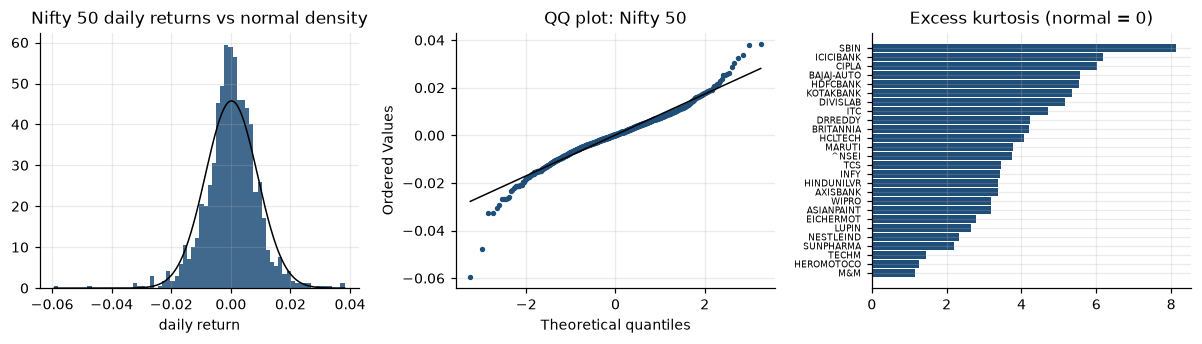

Jarque-Bera rejects normality for 26 of 26 series after Benjamini-Hochberg correction. Excess kurtosis ranges from 1.16 to 8.13. On average 1.23% of days are beyond 3 standard deviations, against 0.27% for a normal distribution.


In [5]:
from scipy import stats as scipy_stats

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
sample = market.to_numpy()
axes[0].hist(sample, bins=70, density=True, color=ACCENT, alpha=0.85)
grid = np.linspace(sample.min(), sample.max(), 300)
axes[0].plot(grid, scipy_stats.norm.pdf(grid, sample.mean(), sample.std()), color="black", lw=1)
axes[0].set_title("Nifty 50 daily returns vs normal density"); axes[0].set_xlabel("daily return")
scipy_stats.probplot(sample, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set(markersize=2.5, color=ACCENT); axes[1].get_lines()[1].set(color="black", lw=1)
axes[1].set_title("QQ plot: Nifty 50")
ordered = distribution["excess_kurtosis"].sort_values()
axes[2].barh([t.replace(".NS", "") for t in ordered.index], ordered, color=ACCENT)
axes[2].tick_params(axis="y", labelsize=6); axes[2].set_title("Excess kurtosis (normal = 0)")
plt.tight_layout(); plt.show()
rejected = int((distribution["p_adjusted"] < 0.05).sum())
print(f"Jarque-Bera rejects normality for {rejected} of {len(distribution)} series after "
      f"Benjamini-Hochberg correction. Excess kurtosis ranges from "
      f"{ordered.min():.2f} to {ordered.max():.2f}. On average "
      f"{distribution['share_beyond_3_sd'].mean() * 100:.2f}% of days are beyond 3 standard "
      "deviations, against 0.27% for a normal distribution.")

### 3.2 Returns show no persistence; volatility shows some

Autocorrelation of returns, and of absolute returns as a proxy for volatility (squared returns are reported too; they are noisier).

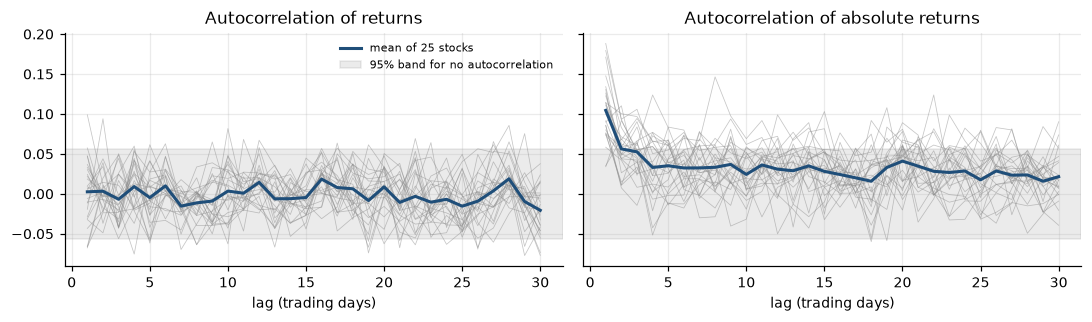

95% band for no autocorrelation: +/-0.056 (1,221 days, 25 stocks)
                  lag 1 (mean)  lags 1-5 (mean)  lags 1-21 (mean)  stocks with lag 1 above band  stocks with lags 1-5 mean above band
series                                                                                                                               
returns                 0.0030           0.0010            0.0000                             2                                     0
absolute returns        0.1040           0.0560            0.0370                            23                                    13
squared returns         0.0840           0.0360            0.0200                            17                                     5



21-day realized volatility (58 non-overlapping windows): mean lag-1 autocorrelation +0.223; positive for 22 of 25 stocks, above the +/-0.257 band for 11.


In [6]:
from statsmodels.tsa.stattools import acf

lags = 30
band = 1.96 / np.sqrt(len(stocks))
series = {"returns": stocks, "absolute returns": stocks.abs(), "squared returns": stocks ** 2}
acfs = {name: pd.DataFrame({t: acf(frame[t], nlags=lags, fft=True)[1:] for t in frame})
        for name, frame in series.items()}
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
for ax, name in zip(axes, ("returns", "absolute returns")):
    ax.plot(range(1, lags + 1), acfs[name], color=GREY, lw=0.5, alpha=0.5)
    ax.plot(range(1, lags + 1), acfs[name].mean(axis=1), color=ACCENT, lw=2,
            label="mean of 25 stocks")
    ax.axhspan(-band, band, color="black", alpha=0.08, label="95% band for no autocorrelation")
    ax.set_title(f"Autocorrelation of {name}"); ax.set_xlabel("lag (trading days)")
axes[0].legend(frameon=False, fontsize=7); plt.tight_layout(); plt.show()
rows = []
for name, frame in acfs.items():
    rows.append({"series": name, "lag 1 (mean)": frame.iloc[0].mean(),
                 "lags 1-5 (mean)": frame.iloc[:5].mean().mean(),
                 "lags 1-21 (mean)": frame.iloc[:21].mean().mean(),
                 "stocks with lag 1 above band": int((frame.iloc[0] > band).sum()),
                 "stocks with lags 1-5 mean above band": int((frame.iloc[:5].mean() > band).sum())})
print(f"95% band for no autocorrelation: +/-{band:.3f} ({len(stocks):,} days, {stocks.shape[1]} stocks)")
print(pd.DataFrame(rows).set_index("series").round(3).to_string())
# persistence of realized volatility itself, on non-overlapping 21-day windows
monthly = ((stocks ** 2).groupby(np.arange(len(stocks)) // 21).mean().iloc[:-1]) ** 0.5
monthly_acf = monthly.apply(lambda column: column.autocorr(1))
monthly_band = 1.96 / np.sqrt(len(monthly))
print(f"\n21-day realized volatility ({len(monthly)} non-overlapping windows): mean lag-1 "
      f"autocorrelation {monthly_acf.mean():+.3f}; positive for {int((monthly_acf > 0).sum())} of "
      f"{len(monthly_acf)} stocks, above the +/-{monthly_band:.3f} band for "
      f"{int((monthly_acf > monthly_band).sum())}.")

### 3.3 Stocks move with their sector

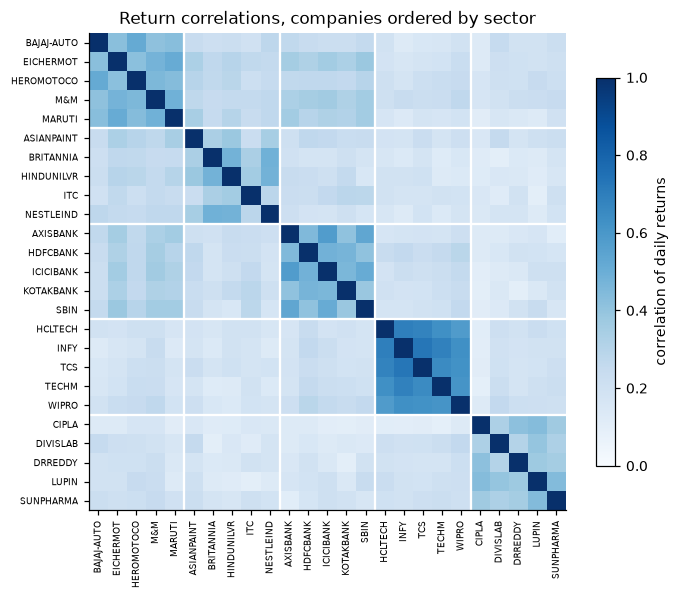

Mean correlation within a sector: 0.464; across sectors: 0.205.
Beta to the Nifty 50 ranges from 0.43 (CIPLA.NS) to 1.20 (M&M.NS).


In [7]:
sector = companies.set_index("ticker")["sector_name"].reindex(stocks.columns)
order = sector.sort_values(kind="stable").index
corr = stocks[order].corr()
fig, ax = plt.subplots(figsize=(6.4, 5.4))
image = ax.imshow(corr, cmap="Blues", vmin=0, vmax=1)
labels = [t.replace(".NS", "") for t in order]
ax.set_xticks(range(len(order)), labels, rotation=90, fontsize=6)
ax.set_yticks(range(len(order)), labels, fontsize=6); ax.grid(False)
for edge in np.flatnonzero(sector[order].to_numpy()[1:] != sector[order].to_numpy()[:-1]) + 0.5:
    ax.axhline(edge, color="white", lw=1.5); ax.axvline(edge, color="white", lw=1.5)
fig.colorbar(image, shrink=0.8, label="correlation of daily returns")
ax.set_title("Return correlations, companies ordered by sector"); plt.tight_layout(); plt.show()
same = sector.to_numpy()[:, None] == sector.to_numpy()[None, :]
upper = np.triu(np.ones_like(same, dtype=bool), k=1)
matrix = stocks.corr().to_numpy()
print(f"Mean correlation within a sector: {matrix[same & upper].mean():.3f}; "
      f"across sectors: {matrix[~same & upper].mean():.3f}.")
beta = stocks.apply(lambda c: c.cov(market)) / market.var()
print(f"Beta to the Nifty 50 ranges from {beta.min():.2f} ({beta.idxmin()}) to "
      f"{beta.max():.2f} ({beta.idxmax()}).")

### 3.4 Fundamentals differ by sector, on a small sample

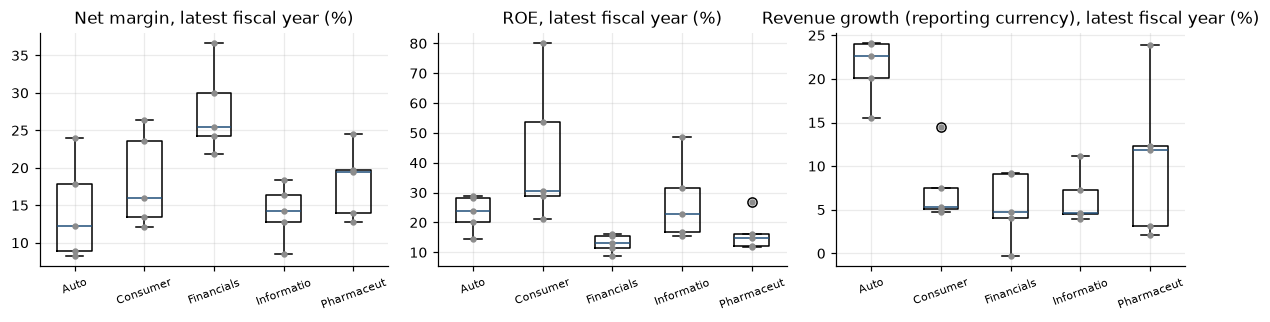

median                            count                   
metric_name            net_margin revenue_growth    roe net_margin revenue_growth roe
sector_name                                                                          
Auto                       0.1220         0.2257 0.2377          5              5   5
Consumer                   0.1598         0.0527 0.3065          5              5   5
Financials                 0.2545         0.0473 0.1312          5              5   5
Information Technology     0.1425         0.0458 0.2298          5              5   5
Pharmaceuticals            0.1940         0.1187 0.1474          5              5   5

In [8]:
latest = (metrics[(metrics["period_type"] == "annual") & metrics["value"].notna()]
          .sort_values("period_end_date").groupby(["ticker", "metric_name"]).tail(1)
          .merge(companies[["ticker", "sector_name"]], on="ticker"))
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, name, title in zip(axes, ("net_margin", "roe", "revenue_growth"),
                           ("Net margin", "ROE", "Revenue growth (reporting currency)")):
    rows = latest[latest["metric_name"] == name]
    groups = [g["value"].to_numpy() * 100 for _, g in rows.groupby("sector_name")]
    names = [s[:10] for s, _ in rows.groupby("sector_name")]
    ax.boxplot(groups, tick_labels=names, medianprops={"color": ACCENT})
    for i, values in enumerate(groups, start=1):
        ax.scatter(np.full(len(values), i), values, s=10, color=GREY, zorder=3)
    ax.set_title(f"{title}, latest fiscal year (%)"); ax.tick_params(axis="x", labelsize=7, rotation=20)
plt.tight_layout(); plt.show()
table = (latest[latest["metric_name"].isin(["net_margin", "roe", "revenue_growth"])]
         .groupby(["sector_name", "metric_name"])["value"].agg(["median", "count"]).unstack())
table

## 4. Interpretation

The printed figures above are the findings; in words:

- **Completeness.** Annual statements are close to complete; quarterly ones are not. Anything that needs quarterly data (TTM multiples, quarterly cash flow) rests on a minority of companies.
- **Fat tails.** Normality is rejected for every series, with clearly positive excess kurtosis and several times more 3-sigma days than a normal distribution implies. Volatility and Sharpe ratios therefore understate tail risk, and the anomaly rules use robust statistics (median, MAD, IQR) rather than means and standard deviations.
- **Returns vs volatility.** Returns show no autocorrelation at any lag, so the project does not try to predict them. Volatility is persistent, but only modestly in this sample: absolute returns are positively autocorrelated at lag 1 for almost every stock and the effect fades within a few days, and month-to-month realized volatility is positively autocorrelated for most stocks but clears the significance band for fewer than half. That is enough structure to justify forecasting volatility (notebook 05), and a reason to expect modest gains over simple baselines rather than large ones.
- **Sector structure.** Stocks correlate far more within a sector than across sectors, which supports sector-based peer groups and is tested directly by clustering (notebook 06).
- **Fundamentals.** Sectors differ on margins and returns on equity, but each box is five companies; the statistical tests in the Data Science Lab quantify how little that sample can establish.

## 5. Limitations

- Five years of prices for 25 large companies listed today: one market phase, and survivorship in the selection.
- About four annual statement periods per company; quarterly history is patchy.
- Infosys reports in USD: its ratios and growth here are in USD (see `docs/methodology.md` 2.4).
- Free, unofficial source (Yahoo Finance via yfinance); the 8 companies added last end one trading day earlier than the rest in this snapshot.
- Correlations and autocorrelations are full-sample descriptions, not forecasts.

*FinSight is an analytics tool, not investment advice.*